In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import yfinance as yf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [66]:
df = yf.download(
    "AAPL",
    start="2015-01-01",
    end="2026-01-01"
)

df.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2015-01-02,24.171757,24.638257,23.733998,24.627201,212818400
2015-01-05,23.490805,24.021421,23.305090,23.941828,257142000
2015-01-06,23.493015,23.751690,23.132638,23.554920,263188400
2015-01-07,23.822435,23.921925,23.590290,23.700835,160423600
2015-01-08,24.737751,24.795235,24.032474,24.149653,237458000


In [67]:
df

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2015-01-02,24.171757,24.638257,23.733998,24.627201,212818400
2015-01-05,23.490805,24.021421,23.305090,23.941828,257142000
2015-01-06,23.493015,23.751690,23.132638,23.554920,263188400
2015-01-07,23.822435,23.921925,23.590290,23.700835,160423600
2015-01-08,24.737751,24.795235,24.032474,24.149653,237458000
...,...,...,...,...,...
2025-12-24,273.066711,274.682309,271.461097,271.600701,17910600
2025-12-26,272.657806,274.622460,272.119264,273.415753,21521800


In [68]:
df.shape

(2766, 5)

In [69]:
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 2766 entries, 2015-01-02 to 2025-12-31
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, AAPL)   2766 non-null   float64
 1   (High, AAPL)    2766 non-null   float64
 2   (Low, AAPL)     2766 non-null   float64
 3   (Open, AAPL)    2766 non-null   float64
 4   (Volume, AAPL)  2766 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 129.7 KB


In [70]:
df.describe()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
count,2766.000000,2766.000000,2766.000000,2766.000000,2.766000e+03
mean,106.036035,107.087194,104.881289,105.939762,1.113994e+08
std,74.119445,74.825185,73.335017,74.040948,6.804243e+07
min,20.548145,20.850666,20.350262,20.470819,1.791060e+07
25%,36.551959,36.971623,36.216504,36.563908,6.488962e+07
50%,88.231133,89.394421,87.339928,88.203324,9.454380e+07
75%,168.189377,169.693584,166.722388,167.946414,1.372937e+08
max,285.413116,287.836529,282.530963,285.423116,6.488252e+08


In [71]:
df.isnull().sum()

Price   Ticker
Close   AAPL      0
High    AAPL      0
Low     AAPL      0
Open    AAPL      0
Volume  AAPL      0
dtype: int64

In [72]:
df["Return"] = df["Close"].pct_change()

In [73]:
df["Return_5"] = df["Close"].pct_change(5)

In [74]:
df["MA10"] = df["Close"].rolling(10).mean()

In [75]:
df["MA20"] = df["Close"].rolling(20).mean()

In [76]:
df["Volatility"] = df["Return"].rolling(10).std()

In [77]:
df["Volume_Change"] = df["Volume"].pct_change()

In [78]:
print(np.isinf(X_train).sum())
print(np.isinf(X_test).sum())

Price          Ticker
Return                   0
Return_5                 0
MA10                     0
MA20                     0
Volatility               0
Volume_Change            0
dtype: int64
Price          Ticker
Return                   0
Return_5                 0
MA10                     0
MA20                     0
Volatility               0
Volume_Change            0
dtype: int64


In [79]:
print(X_train.isna().sum())
print(X_test.isna().sum())

Price          Ticker
Return                   0
Return_5                 0
MA10                     0
MA20                     0
Volatility               0
Volume_Change            0
dtype: int64
Price          Ticker
Return                   0
Return_5                 0
MA10                     0
MA20                     0
Volatility               0
Volume_Change            0
dtype: int64


In [80]:
df = df.replace([np.inf, -np.inf], np.nan)

In [81]:
df = df.dropna()

In [82]:
features = [
    "Return",
    "Return_5",
    "MA10",
    "MA20",
    "Volatility",
    "Volume_Change"
]

X = df[features]
y = df["Target"]

KeyError: 'Target'

In [41]:
split = int(len(df) * 0.8)

X_train = X.iloc[:split]
X_test = X.iloc[split:]

y_train = y.iloc[:split]
y_test = y.iloc[split:]

In [42]:
print("Train infinity:", np.isinf(X_train).sum().sum())
print("Test infinity:", np.isinf(X_test).sum().sum())

print("Train NaN:", X_train.isna().sum().sum())
print("Test NaN:", X_test.isna().sum().sum())

Train infinity: 0
Test infinity: 0
Train NaN: 0
Test NaN: 0


In [43]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [84]:
df["Future_Return"] = df["Close"].shift(-1) / df["Close"] - 1

In [85]:
df["Target"] = np.select(
    [
        df["Future_Return"] > 0.01,
        df["Future_Return"] < -0.01
    ],
    [1, -1],
    default=0
)

In [86]:
df = df.dropna()

In [87]:
df[["Close", "Future_Return", "Target"]].head(10)

Price,Close,Future_Return,Target
Ticker,AAPL,,
Date,,,
2015-01-30,25.902895,0.012547,1
2015-02-02,26.227901,0.000168,0
2015-02-03,26.232313,0.007670,0
2015-02-04,26.433504,0.007138,0
2015-02-05,26.622181,-0.008421,0
2015-02-06,26.397997,0.006642,0
2015-02-09,26.573345,0.019211,1
2015-02-10,27.083853,0.023439,1


In [88]:
print(df["Target"].value_counts())

Target
 0    1525
 1     686
-1     535
Name: count, dtype: int64


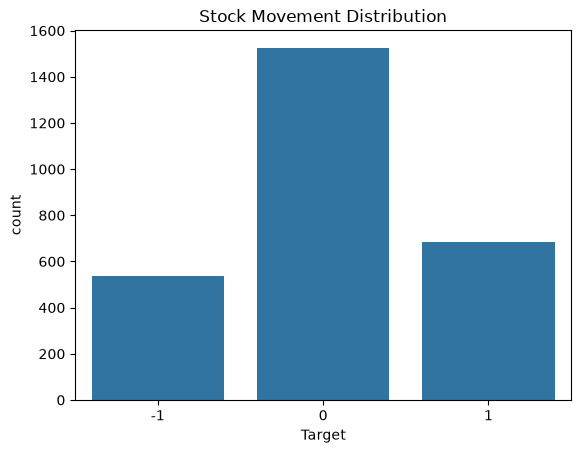

In [89]:
sns.countplot(x=df["Target"])
plt.title("Stock Movement Distribution")
plt.show()

In [90]:
features = [
    "Return",
    "Return_5",
    "MA10",
    "MA20",
    "Volatility",
    "Volume_Change"
]

In [91]:
X = df[features]
y = df["Target"]


In [92]:
X

Price,Return,Return_5,MA10,MA20,Volatility,Volume_Change
Ticker,,,,,,
Date,,,,,,
2015-01-30,-0.014634,0.036998,24.833920,24.461717,0.026189,-0.008182
2015-02-02,0.012547,0.048895,25.113378,24.564524,0.025471,-0.250836
2015-02-03,0.000168,0.087136,25.332921,24.701599,0.025176,-0.172514
2015-02-04,0.007670,0.036857,25.554231,24.848624,0.025176,0.351223
2015-02-05,0.007138,0.012728,25.731399,24.988611,0.024462,-0.397771
...,...,...,...,...,...,...
2025-12-23,0.005130,-0.008193,273.738898,276.557228,0.007424,-0.189485
2025-12-24,0.005324,0.007247,273.243243,276.399655,0.007375,-0.395770


In [93]:
split = int(len(df) * 0.8)

X_train = X.iloc[:split]
X_test = X.iloc[split:]

y_train = y.iloc[:split]
y_test = y.iloc[split:]

In [94]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [95]:
model_lr = LogisticRegression(max_iter=1000)

model_lr.fit(X_train_scaled, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [96]:
model_lr = LogisticRegression(max_iter=1000)

model_lr.fit(X_train_scaled, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [97]:
y_pred_lr = model_lr.predict(X_test_scaled)

In [98]:
accuracy_lr = accuracy_score(y_test, y_pred_lr)

print("Accuracy:", accuracy_lr)

Accuracy: 0.5763636363636364


In [99]:
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

          -1       0.23      0.06      0.10        96
           0       0.62      0.93      0.74       330
           1       0.12      0.02      0.04       124

    accuracy                           0.58       550
   macro avg       0.32      0.34      0.29       550
weighted avg       0.44      0.58      0.47       550



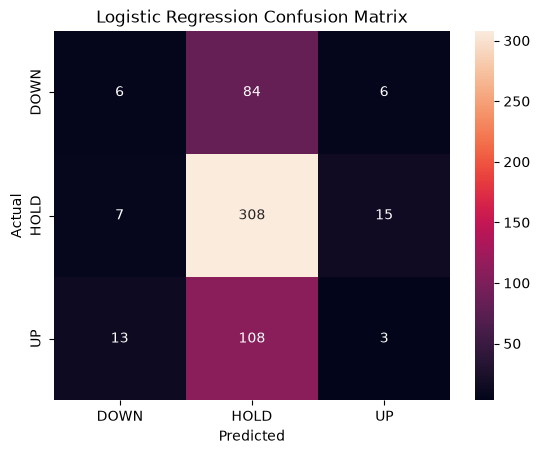

In [100]:
cm = confusion_matrix(y_test, y_pred_lr)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["DOWN", "HOLD", "UP"],
    yticklabels=["DOWN", "HOLD", "UP"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression Confusion Matrix")
plt.show()

In [101]:
model_rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

model_rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [102]:
y_pred_rf = model_rf.predict(X_test)

In [103]:
accuracy_rf = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", accuracy_rf)

Random Forest Accuracy: 0.5745454545454546


In [104]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

          -1       0.23      0.14      0.17        96
           0       0.62      0.92      0.74       330
           1       0.33      0.01      0.02       124

    accuracy                           0.57       550
   macro avg       0.39      0.35      0.31       550
weighted avg       0.48      0.57      0.47       550



In [105]:
print("Logistic Regression:", accuracy_lr)
print("Random Forest:", accuracy_rf)

Logistic Regression: 0.5763636363636364
Random Forest: 0.5745454545454546


In [106]:
if accuracy_rf > accuracy_lr:
    best_model = model_rf
    print("Best Model: Random Forest")
else:
    best_model = model_lr
    print("Best Model: Logistic Regression")

Best Model: Logistic Regression


In [107]:
latest_data = df[features].iloc[-1:]



In [108]:
prediction = best_model.predict(latest_data)

In [109]:
if prediction[0] == 1:
    print("Prediction: UP")
elif prediction[0] == 0:
    print("Prediction: HOLD")
else:
    print("Prediction: DOWN")

Prediction: DOWN


In [110]:
probability = best_model.predict_proba(latest_data)

print(probability)

[[1.00000000e+00 6.45125212e-24 1.66106322e-11]]


In [111]:
classes = best_model.classes_

for cls, prob in zip(classes, probability[0]):
    if cls == 1:
        name = "UP"
    elif cls == 0:
        name = "HOLD"
    else:
        name = "DOWN"

    print(name, ":", round(prob * 100, 2), "%")

DOWN : 100.0 %
HOLD : 0.0 %
UP : 0.0 %


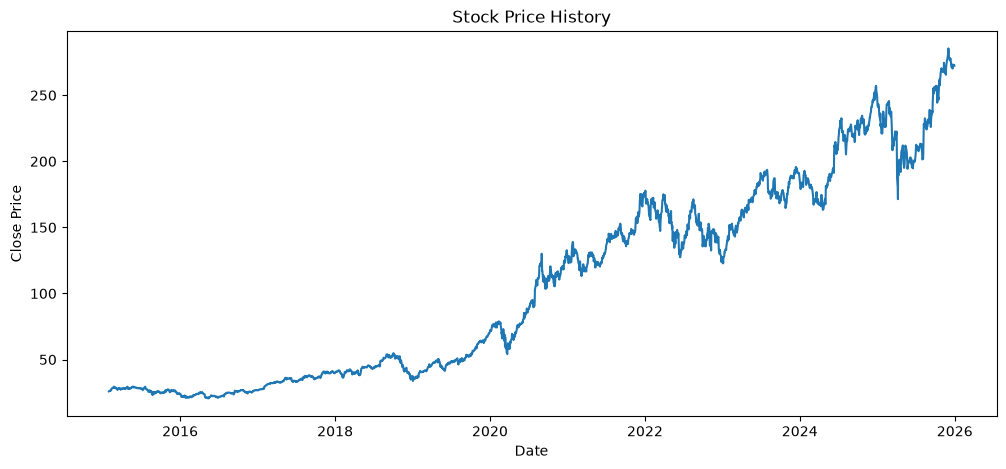

In [112]:
plt.figure(figsize=(12, 5))

plt.plot(df["Close"])

plt.title("Stock Price History")
plt.xlabel("Date")
plt.ylabel("Close Price")

plt.show()

In [113]:
importance = pd.Series(
    model_rf.feature_importances_,
    index=features
).sort_values(ascending=False)

print(importance)

Volatility       0.179183
Return           0.169993
Return_5         0.169495
Volume_Change    0.167585
MA10             0.157902
MA20             0.155842
dtype: float64


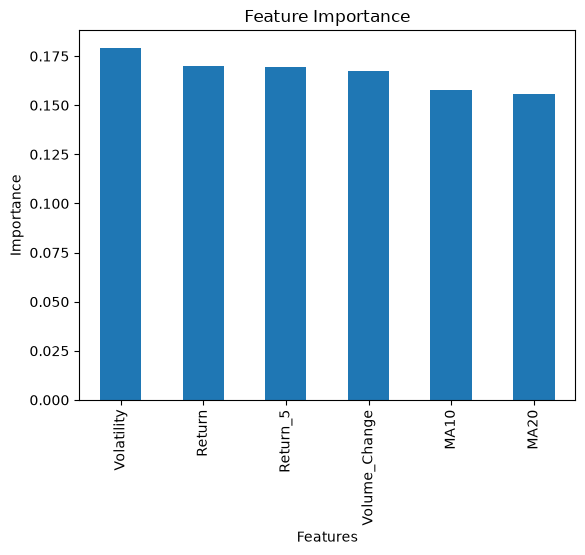

In [114]:
importance.plot(kind="bar")

plt.title("Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance")

plt.show()

In [115]:
import joblib

joblib.dump(best_model, "stock_movement_model.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [116]:
import joblib
import os

os.makedirs("models", exist_ok=True)

joblib.dump(model_lr, "models/stock_movement_model.pkl")
joblib.dump(scaler, "models/scaler.pkl")

print("Model and scaler saved successfully!")

Model and scaler saved successfully!
